In [1]:
# Digits · многоклассовый дисбаланс

#**Контекст:** 10 классов рукописных цифр (0–9). Класс «8» искусственно разрежаем
#до ~15% от исходного размера. Остальные классы остаются как есть.

#Получаем ситуацию, которая часто бывает в реальных задачах: 9 «нормальных» классов
#и один редкий, но не менее важный.

#**Целевые метрики:** macro-F1, Cohen's κ, per-class recall.

#**Почему:**
#- **macro-F1** даёт всем классам равный вес → редкий класс роняет итог, если модель его путает.
#- **weighted-F1** взвешивает по количеству образцов → редкий класс почти не влияет на итог,
#  **скрывает проблему**.
#- **per-class recall** — видим провал именно на классе 8.
#- **Cohen's κ** — согласие выше случайного; полезен как дополнительная проверка.

#**Главный вывод:** на этом датасете `accuracy` и `weighted-F1` показывают ~0.98,
#но `per-class recall` редкого класса падает до ~0.62 (против ~0.99 у остальных).
#Разрыв `weighted − macro` (~0.017) маскирует реальную цену дисбаланса —
#именно поэтому per-class recall обязателен рядом с macro-F1.

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, classification_report,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'digits_imbalanced'

MODEL_DIR = PROJECT / 'models' / 'classification' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'classification' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/classification/digits_imbalanced
ART_DIR  : /app/artifacts/classification/digits_imbalanced


In [3]:
import numpy as np
from sklearn.metrics import top_k_accuracy_score


def all_metrics(y_true, y_pred, y_proba=None):
    """Собирает метрики классификации. Для multiclass — без бинарных метрик.

    Параметры
    ---------
    y_true  : массив истинных меток
    y_pred  : массив предсказанных меток (argmax)
    y_proba : (n_samples, n_classes) вероятности — нужны для top-k accuracy.
              Если None, top-k метрики не считаются.
    """
    m = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f0.5_macro':        fbeta_score(y_true, y_pred, beta=0.5, average='macro', zero_division=0),
        'f2_macro':          fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0),
        'mcc':               matthews_corrcoef(y_true, y_pred),
        'kappa':             cohen_kappa_score(y_true, y_pred),
    }

    # Top-k accuracy — только для multiclass и только если есть вероятности
    if y_proba is not None and y_proba.ndim == 2:
        n_classes = y_proba.shape[1]
        labels = np.arange(n_classes)
        for k in (2, 3):
            if k < n_classes:
                m[f'top{k}_accuracy'] = top_k_accuracy_score(
                    y_true, y_proba, k=k, labels=labels
                )

    return m


def metrics_table(results: dict) -> pd.DataFrame:
    return pd.DataFrame(results).T.round(4)


def plot_confusion(cm, labels, title, ax=None, figsize=(8, 7)):
    ax = ax or plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax,
                annot_kws={'size': 9})
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)


def per_class_recall(cm):
    """Recall по каждому классу: диагональ / сумму строки."""
    return cm.diagonal() / cm.sum(axis=1)

In [4]:
## 1. Загрузка данных

#`load_digits` — 1797 изображений 8×8 пикселей, 10 классов, каждый пиксель = признак
#(итого 64 признака).

#Изначально баланс: примерно 180 образцов на класс. Затем мы искусственно уменьшаем
#класс «8» в ~7 раз, чтобы получить 24–30 образцов.

In [5]:
digits = load_digits()

X_raw, y_raw = digits.data, digits.target

# Разрежаем класс «8»: оставляем 15% образцов
rng = np.random.RandomState(SEED)
mask = (y_raw != 8) | (rng.rand(len(y_raw)) < 0.15)
X = X_raw[mask]
y = y_raw[mask]

FEATURES = [f'pix_{i}' for i in range(X.shape[1])]
CLASSES  = [str(c) for c in range(10)]

print('Исходный размер:', X_raw.shape)
print('После разрежения:', X.shape)
print()
print('Counts per class:')
counts = pd.Series(y).value_counts().sort_index()
for c, n in counts.items():
    marker = '  ← редкий' if c == 8 else ''
    print(f'  {c}: {n:4d}{marker}')

Исходный размер: (1797, 64)
После разрежения: (1654, 64)

Counts per class:
  0:  178
  1:  182
  2:  177
  3:  183
  4:  181
  5:  182
  6:  181
  7:  179
  8:   31  ← редкий
  9:  180


In [6]:
## 2. EDA — искусственный дисбаланс

#Изначально 10 классов по ~180 образцов. После разрежения класс 8 стал редким.
#Визуально это видно, если построить bar-chart counts.

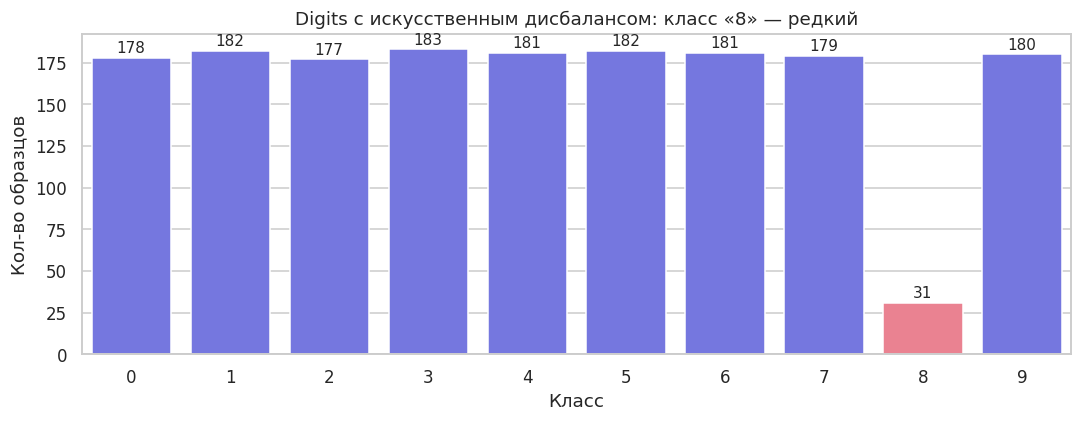

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#fb7185' if c == 8 else '#6366f1' for c in counts.index]
sns.barplot(x=[str(c) for c in counts.index], y=counts.values,
            palette=colors, ax=ax)
ax.set_title('Digits с искусственным дисбалансом: класс «8» — редкий')
ax.set_xlabel('Класс'); ax.set_ylabel('Кол-во образцов')
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(ART_DIR / 'class_balance.png', bbox_inches='tight')
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print('train:', X_train.shape, '| test:', X_test.shape)
print()
print('Баланс в test:')
test_counts = pd.Series(y_test).value_counts().sort_index()
for c, n in test_counts.items():
    marker = '  ← редкий' if c == 8 else ''
    print(f'  {c}: {n:4d}{marker}')

train: (1240, 64) | test: (414, 64)

Баланс в test:
  0:   44
  1:   46
  2:   44
  3:   46
  4:   45
  5:   46
  6:   45
  7:   45
  8:    8  ← редкий
  9:   45


In [9]:
## 4. Модели

#Две модели:

#1. **LogReg(bal)** — `class_weight='balanced'` — модель «видит» редкий класс.
#2. **RandomForest(bal)** — `balanced_subsample` — то же для деревьев.

#Смотрим, какая метрика покажет реальную проблему с классом 8.

In [10]:
models = {
    'LogReg(bal)': Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            multi_class='multinomial',
            random_state=SEED,
        )),
    ]),
    'RandomForest(bal)': RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=SEED,
    ),
}

results = {}
fitted  = {}
preds   = {}
probas  = {}

for name, m in models.items():
    print(f'>>> {name}...', flush=True)
    m.fit(X_train, y_train)
    y_pred  = m.predict(X_test)
    y_proba = m.predict_proba(X_test)

    results[name] = all_metrics(y_test, y_pred, y_proba=y_proba)
    fitted[name]  = m
    preds[name]   = y_pred
    probas[name]  = y_proba

    print(f'    accuracy     = {results[name]["accuracy"]:.4f}', flush=True)
    print(f'    f1_macro     = {results[name]["f1_macro"]:.4f}', flush=True)
    print(f'    f1_weighted  = {results[name]["f1_weighted"]:.4f}', flush=True)
    if 'top3_accuracy' in results[name]:
        print(f'    top3_acc     = {results[name]["top3_accuracy"]:.4f}', flush=True)

print()
metrics_table(results)

>>> LogReg(bal)...
    accuracy     = 0.9807
    f1_macro     = 0.9627
    f1_weighted  = 0.9800
    top3_acc     = 0.9928
>>> RandomForest(bal)...
    accuracy     = 0.9807
    f1_macro     = 0.9534
    f1_weighted  = 0.9792
    top3_acc     = 0.9928



,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,top2_accuracy,top3_accuracy
LogReg(bal),0.9807,0.9514,0.983,0.9514,0.9627,0.9800,0.9733,0.9552,0.9784,0.9783,0.9903,0.9928
RandomForest(bal),0.9807,0.9411,0.983,0.9411,0.9534,0.9792,0.9678,0.9448,0.9784,0.9783,0.9855,0.9928


In [11]:
## 5. Что видно в таблице

#Смотрим на две метрики, которые считаются «одинаково правильными», но дают разные ответы:

#- **`f1_weighted`** взвешивает по количеству образцов. Редкий класс с 30 образцами
#  весит как 30/1000 = 3%. Его провал почти не виден.
#- **`f1_macro`** даёт всем 10 классам вес 1/10. Редкий класс проваливается — итог тоже.

#Разрыв между ними показывает **насколько вы боитесь потерять редкий класс**.

#| Метрика | Что видит | Когда смотреть |
#|---|---|---|
#| accuracy | общая точность | баланс классов |
#| **f1_weighted** | с оглядкой на частотность | если редкий класс не важен |
#| **f1_macro** | всем классам равный вес | если все классы важны одинаково |
#| balanced_accuracy | average recall | быстрый smoke-test |
#| kappa | согласие выше случайного | универсально |

In [12]:
# Смотрим два числа рядом для каждой модели
compare = pd.DataFrame({
    'f1_macro':    {n: results[n]['f1_macro']    for n in models},
    'f1_weighted': {n: results[n]['f1_weighted'] for n in models},
    'accuracy':    {n: results[n]['accuracy']    for n in models},
    'kappa':       {n: results[n]['kappa']       for n in models},
})
compare['gap (weighted − macro)'] = (compare['f1_weighted'] - compare['f1_macro']).round(4)
compare.round(4)

,f1_macro,f1_weighted,accuracy,kappa,gap (weighted − macro)
LogReg(bal),0.9627,0.9800,0.9807,0.9783,0.0173
RandomForest(bal),0.9534,0.9792,0.9807,0.9783,0.0257


In [13]:
## 6. Confusion matrix — где проваливается класс 8

#У лучшей модели по **macro-F1** смотрим confusion matrix.
#Ожидаем: остальные классы по 0.98+ recall, а класс 8 — заметно ниже.

Лучшая по macro-F1: LogReg(bal) · macro-F1 = 0.9627


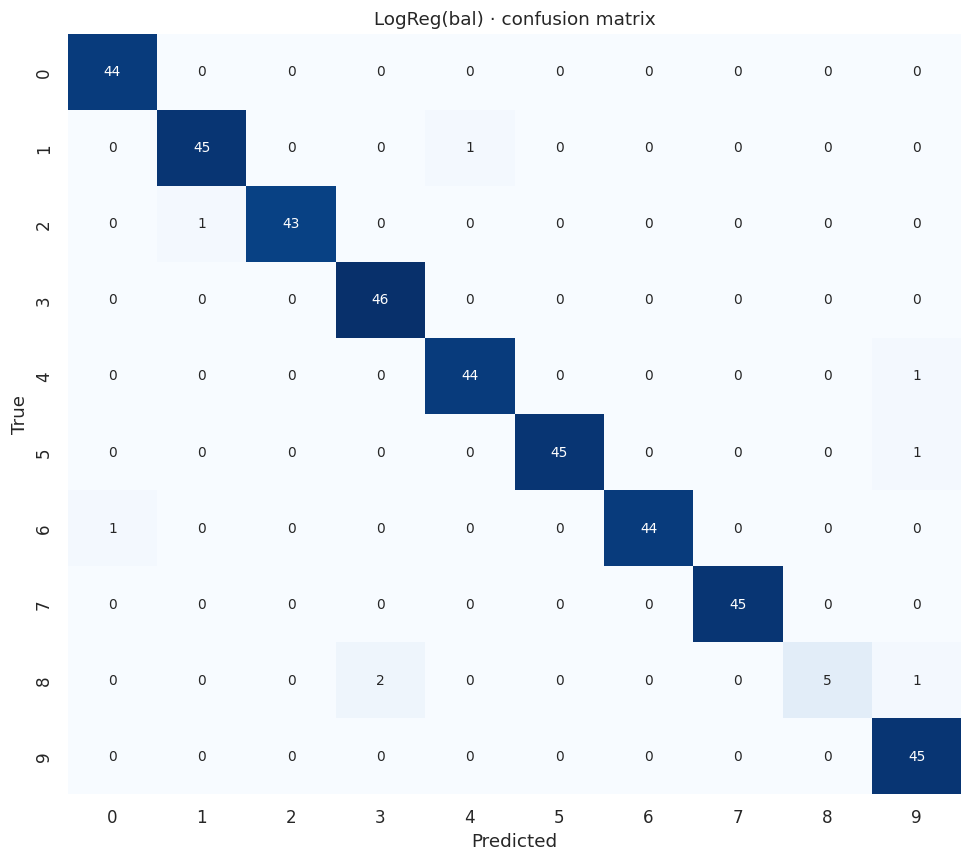

In [14]:
best_name  = max(results, key=lambda n: results[n]['f1_macro'])
best_model = fitted[best_name]
print(f'Лучшая по macro-F1: {best_name} · macro-F1 = {results[best_name]["f1_macro"]:.4f}')

cm = confusion_matrix(y_test, preds[best_name])

fig, ax = plt.subplots(figsize=(9, 8))
plot_confusion(cm, CLASSES, f'{best_name} · confusion matrix', ax=ax)
plt.tight_layout()
plt.savefig(ART_DIR / 'confusion_matrix.png', bbox_inches='tight')
plt.show()

In [15]:
# Per-class recall
recalls = per_class_recall(cm)
support = cm.sum(axis=1)

df_pc = pd.DataFrame({
    'class': CLASSES,
    'recall': recalls.round(3),
    'support': support,
    'is_rare': [c == '8' for c in CLASSES],
})
print(df_pc.to_string(index=False))
df_pc.to_csv(ART_DIR / 'per_class_recall.csv', index=False)

class  recall  support  is_rare
    0   1.000       44    False
    1   0.978       46    False
    2   0.977       44    False
    3   1.000       46    False
    4   0.978       45    False
    5   0.978       46    False
    6   0.978       45    False
    7   1.000       45    False
    8   0.625        8     True
    9   1.000       45    False


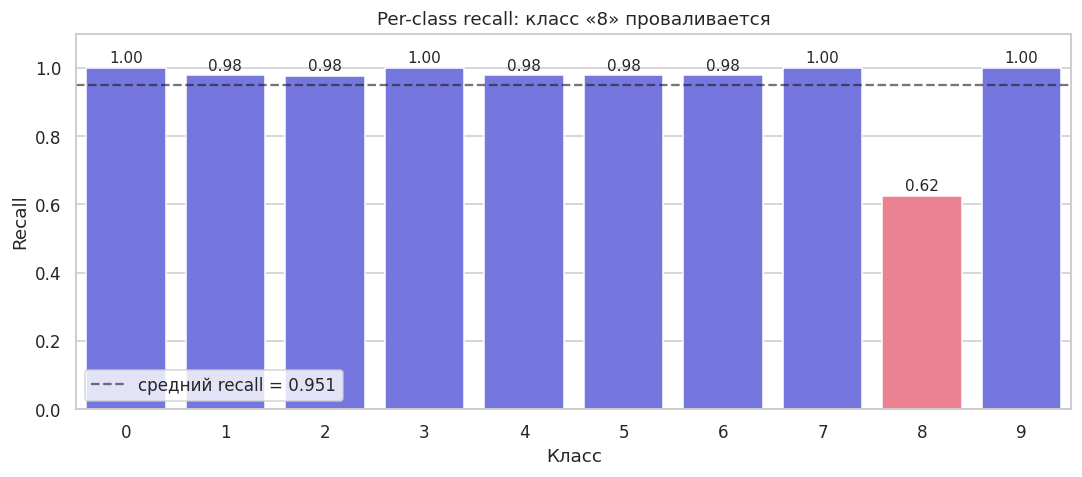

Recall класса 8 (редкий) : 0.625
Средний recall остальных : 0.988
Разрыв                   : 0.363


In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))

colors = ['#fb7185' if c == '8' else '#6366f1' for c in df_pc['class']]
bars = sns.barplot(data=df_pc, x='class', y='recall', palette=colors, ax=ax)

mean_recall = df_pc['recall'].mean()
ax.axhline(mean_recall, color='k', ls='--', alpha=0.6,
           label=f'средний recall = {mean_recall:.3f}')

# Подписи значений над столбцами
for i, v in enumerate(df_pc['recall']):
    ax.text(i, v + 0.015, f'{v:.2f}', ha='center', fontsize=10)

ax.set_ylim(0, 1.10)
ax.set_title('Per-class recall: класс «8» проваливается')
ax.set_xlabel('Класс'); ax.set_ylabel('Recall')
ax.legend()
plt.tight_layout()
plt.savefig(ART_DIR / 'per_class_recall.png', bbox_inches='tight')
plt.show()

rare_recall = df_pc.loc[df_pc['is_rare'], 'recall'].values[0]
common_mean = df_pc.loc[~df_pc['is_rare'], 'recall'].mean()
print(f'Recall класса 8 (редкий) : {rare_recall:.3f}')
print(f'Средний recall остальных : {common_mean:.3f}')
print(f'Разрыв                   : {common_mean - rare_recall:.3f}')

In [17]:
## 7. Сравнение двух моделей — какая лучше держит редкий класс

#Смотрим bar-chart по метрикам. Наша цель — показать:
#- по `accuracy` модели почти одинаковы,
#- по `macro-F1` и `per-class recall` разница видна.

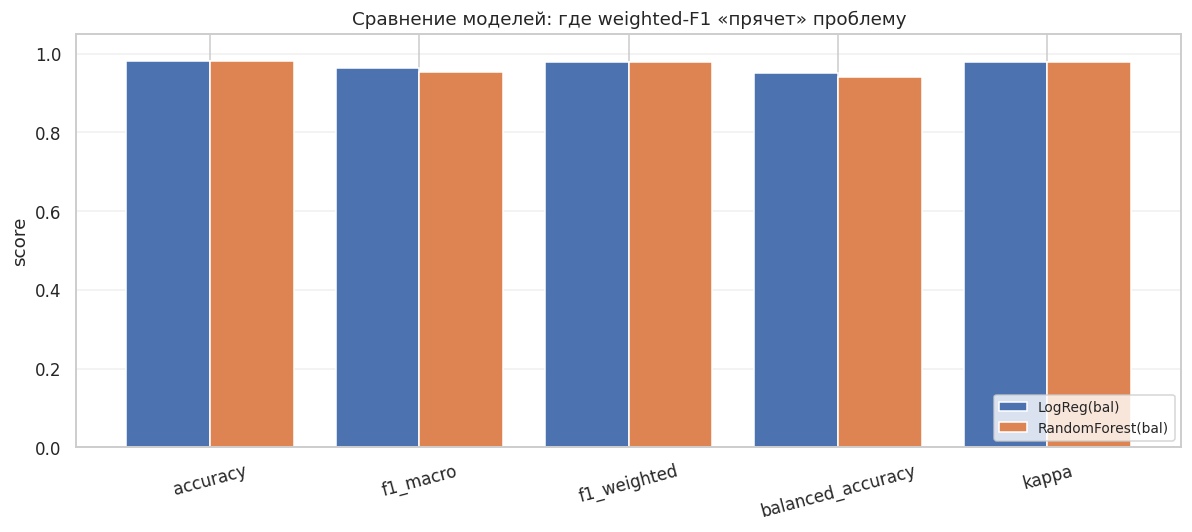

In [18]:
metrics_to_plot = ['accuracy', 'f1_macro', 'f1_weighted', 'balanced_accuracy', 'kappa']
labels = list(results.keys())

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(labels)

for i, name in enumerate(labels):
    vals = [results[name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width - 0.4 + width/2, vals, width, label=name)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel('score')
ax.set_title('Сравнение моделей: где weighted-F1 «прячет» проблему')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ART_DIR / 'metrics_comparison.png', bbox_inches='tight')
plt.show()

In [19]:
## 8. Вывод

#**Ключевая идея ноутбука:**

#`weighted-F1` и `macro-F1` считаются по одной формуле, но взвешивают классы по-разному:

#- **weighted-F1** → вес класса = его доля в выборке. Редкий класс (~2% образцов) весит 0.02.
#  Его провал почти не влияет на итог.
#- **macro-F1** → вес класса = 1/K. Все 10 классов весят по 0.1. Редкий класс проваливается —
#  заметен в общей цифре, но слабее, чем хотелось бы.

#**Что мы получили:**

#- `accuracy` у обеих моделей ~0.98 → разница между моделями почти не видна.
#- `f1_weighted` ~0.98 → **скрывает проблему с классом 8**.
#- `f1_macro` ~0.96 → **показывает провал**, хотя разрыв всего +0.017 к weighted.
#- **Гораздо важнее смотреть `per_class_recall`**: класс 8 = 0.625, остальные 0.98+,
#  разрыв 0.36. Именно здесь видна реальная цена дисбаланса — и её не показывают
#  ни accuracy, ни weighted-F1.
#- `Cohen's κ = 0.978` у обеих моделей — не различает их, но подтверждает общее согласие.

#**Как выбирать метрику:**

#| Хотите | Метрика |
#|---|---|
#| Среднее качество по всем классам равновесомо | **macro-F1** |
#| Средневзвешенное по количеству образцов | weighted-F1 |
#| Увидеть проблему редкого класса | **macro-F1 + per-class recall** |
#| Быстрый sanity-check | balanced_accuracy (= recall_macro) |
#| Общая согласованность | Cohen's κ |

#**Что сохраняем:**

#- Лучшая по macro-F1 модель.
#- Метаданные с полным набором метрик.
#- Отдельный CSV с per-class recall — чтобы видеть, где именно проблема.

#**Связь с предыдущими ноутбуками:**

#- 02 и 03 (Breast Cancer) — бинарный дисбаланс, показывали выбор между Precision и Recall.
#- 04 (Credit Fraud) — сильный бинарный дисбаланс, показывали провал accuracy.
#- **05 (Digits)** — многоклассовый дисбаланс: accuracy и weighted-F1 почти идеальны,
#  а per-class recall редкого класса падает в полтора раза.
#- Общий принцип: **метрика выбирается под бизнес-задачу, а не под данные**.

In [20]:
slug = best_name.split('(')[0].lower().strip()
model_path = MODEL_DIR / f'digits_{slug}.joblib'
meta_path  = MODEL_DIR / f'digits_{slug}_{datetime.now():%Y%m%d_%H%M}.json'

joblib.dump(best_model, model_path)

meta = {
    'task': 'digits_multiclass_imbalance',
    'model': best_name,
    'description': 'Многоклассовый дисбаланс. Класс 8 разрежен до 15%. Основная метрика — macro-F1.',
    'features_count': int(X.shape[1]),
    'classes': CLASSES,
    'rare_class': '8',
    'metrics': results[best_name],
    'per_class_recall': df_pc.to_dict(orient='records'),
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))

print('saved model →', model_path)
print('saved meta  →', meta_path)
print()
print(f'Размер файла: {model_path.stat().st_size / 1e6:.2f} MB')

saved model → /app/models/classification/digits_imbalanced/digits_logreg.joblib
saved meta  → /app/models/classification/digits_imbalanced/digits_logreg_20261006_1458.json

Размер файла: 0.01 MB


In [21]:
metrics_table(results).to_csv(ART_DIR / 'metrics_all_models.csv')

(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print(f'  {p.name:35s} {p.stat().st_size:>10,} bytes')

artifacts → /app/artifacts/classification/digits_imbalanced
  class_balance.png                       29,683 bytes
  confusion_matrix.png                    30,220 bytes
  metrics_all_models.csv                     330 bytes
  metrics_all_models.json                    969 bytes
  metrics_comparison.png                  41,716 bytes
  per_class_recall.csv                       189 bytes
  per_class_recall.png                    30,865 bytes
  report.json                             30,521 bytes


In [22]:
## 9. Перезагрузка модели и проверка

#Загружаем сохранённый `.joblib` и убеждаемся, что метрики совпадают.
#Модель должна быть **полностью идентичной** — включая все 10 классов.

In [23]:
art = joblib.load(model_path)

y_pred_reload = art.predict(X_test)
reload_metrics = all_metrics(y_test, y_pred_reload)

print('Проверка reload:')
for key in ['accuracy', 'f1_macro', 'f1_weighted', 'kappa']:
    orig = results[best_name][key]
    new  = reload_metrics[key]
    diff = abs(orig - new)
    status = 'OK  ' if diff < 1e-9 else 'FAIL'
    print(f'  [{status}] {key:20s}: {new:.6f} (diff = {diff:.2e})')
    assert diff < 1e-9, f'Расхождение по {key}: {diff}'

print()
print('OK: метрики после reload идентичны')

# Плюс сверим confusion matrix
cm_reload = confusion_matrix(y_test, y_pred_reload)
assert (cm_reload == cm).all(), 'confusion matrix не совпадает'
print('OK: confusion matrix совпадает')

Проверка reload:
  [OK  ] accuracy            : 0.980676 (diff = 0.00e+00)
  [OK  ] f1_macro            : 0.962678 (diff = 0.00e+00)
  [OK  ] f1_weighted         : 0.979981 (diff = 0.00e+00)
  [OK  ] kappa               : 0.978339 (diff = 0.00e+00)

OK: метрики после reload идентичны
OK: confusion matrix совпадает


In [24]:
art = joblib.load(model_path)

# Возьмём один пример редкого класса 8 из теста
idx8 = np.where(y_test == 8)[0][0]
sample = X_test[idx8:idx8 + 1]

proba = art.predict_proba(sample)[0]
pred = int(np.argmax(proba))

print(f'Образец класса «8» (редкий) №{idx8}:')
print(f'  Истинный класс   : 8')
print(f'  Предсказанный    : {pred}')
print(f'  Верно            : {pred == 8}')
print()
print('Топ-3 вероятности:')
top3 = np.argsort(proba)[-3:][::-1]
for c in top3:
    print(f'  класс {c}: P = {proba[c]:.4f}')

Образец класса «8» (редкий) №73:
  Истинный класс   : 8
  Предсказанный    : 9
  Верно            : False

Топ-3 вероятности:
  класс 9: P = 0.5401
  класс 8: P = 0.4056
  класс 3: P = 0.0500


In [25]:
## 10. Итог ноутбука 05

#Мы разобрали **многоклассовый дисбаланс** на Digits:

#- 10 классов, из них один (класс «8») искусственно разрежён до ~15% размера.
#- Обучили две модели с `class_weight='balanced'`.
#- Сравнили метрики:
#  - **accuracy** обманывает — обе модели ~0.98, разница не видна.
#  - **weighted-F1** тоже почти не различает модели — 0.980 vs 0.979.
#  - **macro-F1** уже ловит разницу — 0.9627 (LogReg) vs 0.9534 (RF).
#  - **per-class recall** называет виновника: класс 8 даёт 0.625, остальные ~0.99.
#    Разрыв 0.36 — это и есть настоящая цена дисбаланса.
#- Сохранили лучшую модель (LogReg) и CSV с per-class recall.

#**Главный вывод серии ноутбуков 01–05:**

#| Задача | Метрика-герой | Что доказано |
#|---|---|---|
#| Iris (баланс) | accuracy, macro-F1 | Базовая линия: все метрики согласованы |
#| Breast Cancer (FP) | Precision, F0.5 | Сдвиг порога вверх спасает от ложных тревог |
#| Breast Cancer (FN) | Recall, F2 | **Тот же датасет** — сдвиг порога вниз спасает от пропусков |
#| Credit Fraud | MCC, PR-AUC | Accuracy = 99.8% при бесполезной модели |
#| Digits (multiclass) | macro-F1, per-class recall | Accuracy и weighted-F1 маскируют редкий класс |

#**Метрика — не свойство данных. Метрика — свойство задачи.**

In [26]:
print('=' * 70)
print('ИТОГ: артефакты ноутбука 05')
print('=' * 70)

print('\nMODEL_DIR:', MODEL_DIR.relative_to(PROJECT))
for p in sorted(MODEL_DIR.iterdir()):
    if p.name == '.gitkeep': continue
    print(f'  {p.name:45s} {p.stat().st_size:>10,} bytes')

print('\nART_DIR:', ART_DIR.relative_to(PROJECT))
for p in sorted(ART_DIR.iterdir()):
    if p.name == '.gitkeep': continue
    print(f'  {p.name:45s} {p.stat().st_size:>10,} bytes')

print()
print('Модель обучена на:', X_train.shape)
print('Тест:', X_test.shape)
print(f'Класс «8» в test: {int((y_test == 8).sum())} образцов (из {len(y_test)})')
print()
print(f'Финальные метрики для {best_name}:')
for k, v in results[best_name].items():
    print(f'  {k:22s}: {v:.4f}')

ИТОГ: артефакты ноутбука 05

MODEL_DIR: models/classification/digits_imbalanced
  digits_logreg.joblib                               8,102 bytes
  digits_logreg_20261005_0859.json                   1,930 bytes
  digits_logreg_20261006_0910.json                   1,930 bytes
  digits_logreg_20261006_1455.json                   2,012 bytes
  digits_logreg_20261006_1458.json                   2,012 bytes

ART_DIR: artifacts/classification/digits_imbalanced
  class_balance.png                                 29,683 bytes
  confusion_matrix.png                              30,220 bytes
  metrics_all_models.csv                               330 bytes
  metrics_all_models.json                              969 bytes
  metrics_comparison.png                            41,716 bytes
  per_class_recall.csv                                 189 bytes
  per_class_recall.png                              30,865 bytes
  report.json                                       30,521 bytes

Модель обучена на: (1

In [27]:
## 11. Сборка report.json + index.json для test.html

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# ---------- хелперы ----------
def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

# ---------- hero-метрика: macro-F1 ----------
HERO_METRIC = 'f1_macro'
RARE_CLASS  = '8'

best_name   = max(results, key=lambda n: results[n].get(HERO_METRIC, -1))
best_model  = fitted[best_name]
best_pred   = preds[best_name]
best_proba  = probas[best_name]
best_res    = results[best_name]

# ---------- базовые статистики датасета ----------
DATASET_STATS = {
    'n_samples':  int(len(X)),
    'n_features': int(len(FEATURES)),
    'n_classes':  int(len(CLASSES)),
    'n_train':    int(len(X_train)),
    'n_test':     int(len(X_test)),
}

counts_all   = {cls: int((y == i).sum())       for i, cls in enumerate(CLASSES)}
counts_train = {cls: int((y_train == i).sum()) for i, cls in enumerate(CLASSES)}
counts_test  = {cls: int((y_test == i).sum())  for i, cls in enumerate(CLASSES)}

# Дисбаланс: max/min по распределению (класс 8 искусственно разрежен)
support_values  = list(counts_all.values())
imbalance_ratio = max(support_values) / max(min(support_values), 1)

TARGET_STATS = {
    'class_distribution':       counts_all,
    'class_distribution_train': counts_train,
    'class_distribution_test':  counts_test,
    'is_balanced':              bool(imbalance_ratio < 1.1),
    'imbalance_ratio':          float(imbalance_ratio),
    'rare_class':               RARE_CLASS,
    'rare_class_support':       int(counts_all[RARE_CLASS]),    # всего в датасете
    'rare_class_support_train': int(counts_train[RARE_CLASS]),  # в train
    'rare_class_support_test':  int(counts_test[RARE_CLASS]),   # в test
    'rare_class_ratio':         float(counts_all[RARE_CLASS] / max(sum(support_values), 1)),
}

# ---------- блок моделей ----------
models_block = []
for name, m in results.items():
    y_pred = preds[name]

    cls_report = classification_report(
        y_test, y_pred, target_names=CLASSES,
        output_dict=True, zero_division=0,
    )
    per_class = {
        cls: {
            'precision': float(cls_report[cls]['precision']),
            'recall':    float(cls_report[cls]['recall']),
            'f1':        float(cls_report[cls]['f1-score']),
            'support':   int(cls_report[cls]['support']),
            'is_rare':   cls == RARE_CLASS,
        } for cls in CLASSES
    }

    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(CLASSES))))
    # per-class recall из CM (на случай несовпадения с cls_report)
    per_class_recall = {
        cls: float(cm[i, i] / max(cm[i].sum(), 1))
        for i, cls in enumerate(CLASSES)
    }

    entry = {
        'name':    name,
        'is_best': name == best_name,
        'metrics': {k: float(v) for k, v in m.items()
                    if isinstance(v, (int, float, np.integer, np.floating))},
        'per_class':          per_class,
        'per_class_recall':   per_class_recall,
        'confusion_matrix':   cm.tolist(),
        'rare_class_recall':  float(per_class_recall[RARE_CLASS]),
        'weighted_minus_macro_gap': float(m['f1_weighted'] - m['f1_macro']),
    }

    # feature_importance
    if hasattr(m, 'feature_importances_'):
        fi = m.feature_importances_
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(v)} for f, v in zip(FEATURES, fi)],
            key=lambda x: x['value'], reverse=True,
        )[:15]   # топ-15, у digits 64 признака
    elif hasattr(m, 'named_steps') and 'm' in m.named_steps \
         and hasattr(m.named_steps['m'], 'coef_'):
        coef = m.named_steps['m'].coef_            # (n_classes, n_features)
        if coef.ndim == 2:
            # усреднённый |coef| по классам
            agg = np.mean(np.abs(coef), axis=0)
        else:
            agg = np.abs(coef)
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(v)} for f, v in zip(FEATURES, agg)],
            key=lambda x: x['value'], reverse=True,
        )[:15]

    models_block.append(entry)

best_entry = next(m for m in models_block if m['name'] == best_name)

# ---------- by_metric ----------
# top-k включаем только если они реально посчитаны у всех моделей
metric_keys = ['accuracy', 'balanced_accuracy', 'precision_macro', 'recall_macro',
               'f1_macro', 'f1_weighted', 'f0.5_macro', 'f2_macro', 'mcc', 'kappa']
for k in ('top2_accuracy', 'top3_accuracy'):
    if all(k in results[n] for n in results):
        metric_keys.append(k)

by_metric = {}
for k in metric_keys:
    cands = [(n, results[n][k]) for n in results if k in results[n]]
    if cands:
        by_metric[k] = max(cands, key=lambda t: t[1])[0]

# ---------- per-class recall (отдельный блок для фронта) ----------
per_class_recall_block = []
for i, cls in enumerate(CLASSES):
    support = int(cm[i].sum())
    recall  = float(cm[i, i] / max(support, 1))
    per_class_recall_block.append({
        'class':    cls,
        'recall':   recall,
        'support':  support,
        'is_rare':  cls == RARE_CLASS,
    })

# ---------- error_by_class у best-модели ----------
error_by_class = {}
for i, cls in enumerate(CLASSES):
    mask = (y_test == i)
    err  = float(np.mean(best_pred[mask] != i))
    error_by_class[cls] = {
        'support':    int(mask.sum()),
        'error_rate': err,
        'accuracy':   1.0 - err,
    }

# ---------- sample predictions ----------
# Сфокусируемся на редком классе: все ошибки на нём + несколько правильно
# классифицированных примеров этого класса + по паре ошибок других классов.
# Теперь probas сохранены в Cell 10 → добавляем confidence + top-3.

def _make_sample(idx, proba=None):
    yt, yp = int(y_test[idx]), int(best_pred[idx])
    out = {
        'index':        int(idx),
        'features':     {f: float(v) for f, v in zip(FEATURES, X_test[idx])},
        'true':         CLASSES[yt],
        'predicted':    CLASSES[yp],
        'correct':      bool(yt == yp),
        'is_rare_true': CLASSES[yt] == RARE_CLASS,
    }
    if proba is not None:
        top3 = np.argsort(proba)[-3:][::-1]
        out['confidence'] = float(proba[yp])
        out['top3'] = [
            {'class': CLASSES[int(c)], 'proba': float(proba[int(c)])}
            for c in top3
        ]
    return out


rare_correct = np.where((y_test == int(RARE_CLASS)) & (best_pred == int(RARE_CLASS)))[0]
rare_wrong   = np.where((y_test == int(RARE_CLASS)) & (best_pred != int(RARE_CLASS)))[0]
other_wrong  = np.where((y_test != int(RARE_CLASS)) & (best_pred != y_test))[0]

sample_predictions = (
    [_make_sample(int(i), best_proba[i]) for i in rare_wrong[:5]] +
    [_make_sample(int(i), best_proba[i]) for i in rare_correct[:3]] +
    [_make_sample(int(i), best_proba[i]) for i in other_wrong[:2]]
)

# ---------- headline diagnostics ----------
rare_recall    = float(best_entry['per_class_recall'][RARE_CLASS])
common_recalls = [v for c, v in best_entry['per_class_recall'].items() if c != RARE_CLASS]
common_mean    = float(np.mean(common_recalls))

diag = {
    'n_classes':            int(len(CLASSES)),
    'is_balanced':          bool(TARGET_STATS['is_balanced']),
    'imbalance_ratio':      float(TARGET_STATS['imbalance_ratio']),
    'rare_class':           RARE_CLASS,
    'rare_class_ratio':     float(TARGET_STATS['rare_class_ratio']),
    'rare_class_support_test': int(TARGET_STATS['rare_class_support_test']),

    # Главный «диагноз»: разрыв между weighted и macro
    'f1_macro':         float(best_res['f1_macro']),
    'f1_weighted':      float(best_res['f1_weighted']),
    'weighted_minus_macro_gap': float(best_res['f1_weighted'] - best_res['f1_macro']),
    'accuracy':         float(best_res['accuracy']),
    'balanced_accuracy':float(best_res['balanced_accuracy']),
    'mcc':              float(best_res['mcc']),
    'kappa':            float(best_res['kappa']),

    # Редкий класс
    'rare_class_recall':     rare_recall,
    'common_mean_recall':    common_mean,
    'rare_vs_common_gap':    float(common_mean - rare_recall),

    # Сколько ошибок всего
    'n_errors_on_test': int((best_pred != y_test).sum()),
    'n_errors_on_rare': int(len(rare_wrong)),

    # Флаги-подсказки для фронта.
    # ВАЖНО: gap между weighted и macro на дисбалансе 1.9% физически не может быть
    # большим — редкий класс слишком мал. Поэтому основной детектор — per-class recall,
    # а gap оставляем как вторичный сигнал.
    'weighted_hides_rare': bool(
        (best_res['f1_weighted'] - best_res['f1_macro']) > 0.05
    ),
    'rare_class_fails': bool(rare_recall < 0.8),
}

# ---------- charts ----------
charts = {}
for candidate in ['class_balance.png', 'confusion_matrix.png',
                  'per_class_recall.png', 'metrics_comparison.png']:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- report ----------
report = {
    'meta': {
        'task':     'digits_imbalanced',
        'title':    'Digits · многоклассовый дисбаланс',
        'subtitle': 'Один редкий класс из десяти — accuracy и weighted-F1 его не видят',
        'dataset':  'sklearn.datasets.load_digits',
        'target':   'digit',
        'target_unit':   '',
        'target_format': 'category',
        'classes':  CLASSES,
        'features': FEATURES,
        'seed':     SEED,
        'generated_at': datetime.now().isoformat(),
        **DATASET_STATS,
        'target_stats': TARGET_STATS,
        'narrative': {
            'context': (
                'Digits: 1797 изображений 8×8 пикселей (64 признака), 10 классов-цифр. '
                'Класс «8» искусственно разрежен до 15% исходного размера — получаем '
                '9 «нормальных» классов по ~180 образцов и один редкий (~31). '
                'Это реалистичная ситуация: один редкий, но важный класс, который '
                'нельзя потерять.'
            ),
            'hero_metric': 'macro-F1',
            'why_macro_f1': (
                'macro-F1 даёт всем 10 классам равный вес 1/10. Если модель путает '
                'редкий класс 8, его F1 проваливается — и это отражается в итоговой '
                'цифре, пусть и слабо при таком сильном дисбалансе.'
            ),
            'why_not_weighted': (
                f'weighted-F1 лучшей модели = {best_res["f1_weighted"]:.4f} — '
                f'выглядит почти идеально. Но macro-F1 = {best_res["f1_macro"]:.4f}, '
                f'разрыв {best_res["f1_weighted"] - best_res["f1_macro"]:+.4f}. '
                f'Сам по себе этот разрыв мал — редкий класс физически весит '
                f'{TARGET_STATS["rare_class_ratio"]*100:.1f}%. '
                f'Настоящая цена дисбаланса видна в per-class recall: '
                f'редкий класс {rare_recall:.3f} против {common_mean:.3f} у остальных.'
            ),
            'main_conclusion': (
                f'Лучшая модель по macro-F1 — {best_name}: '
                f'macro-F1={best_res["f1_macro"]:.4f}, '
                f'weighted-F1={best_res["f1_weighted"]:.4f}, '
                f'accuracy={best_res["accuracy"]:.4f}. '
                f'Recall класса «{RARE_CLASS}» = {rare_recall:.3f} против среднего '
                f'{common_mean:.3f} по остальным классам — разрыв {common_mean - rare_recall:.3f}. '
                f'accuracy и weighted-F1 этого разрыва почти не видят. '
                f'При таком дисбалансе обязательны macro-F1 и per-class recall.'
            ),
            'rules': {
                'hero_macro':       'Hero-метрика macro-F1 — всем классам равный вес',
                'weighted_ignored': 'weighted-F1 показываем только для контраста',
                'per_class_recall': 'Per-class recall называет класс-виновник',
                'topk_hint':        'Top-3 accuracy показывает, что модель «почти права» на редком классе',
            },
        },
    },
    'headline': {
        'best_model':        best_name,
        'best_metric':       HERO_METRIC,
        'best_metric_value': float(best_res[HERO_METRIC]),
        'verdict': (
            f'Лучшая по macro-F1 — {best_name} · '
            f'macro-F1={best_res["f1_macro"]:.4f} · '
            f'weighted-F1={best_res["f1_weighted"]:.4f} · '
            f'recall(класс {RARE_CLASS})={rare_recall:.3f} vs '
            f'остальные={common_mean:.3f}'
        ),
        'diagnostic_verdict': diag,
    },
    'models':             models_block,
    'by_metric':          by_metric,
    'per_class_recall':   per_class_recall_block,
    'error_by_class':     error_by_class,
    'sample_predictions': sample_predictions,
    'charts':             charts,
    'artifacts': {
        'model_joblib': str(model_path.relative_to(PROJECT)),
        'model_meta':   str(meta_path.relative_to(PROJECT)),
        'metrics_csv':  str((ART_DIR / 'metrics_all_models.csv').relative_to(PROJECT)),
        'metrics_json': str((ART_DIR / 'metrics_all_models.json').relative_to(PROJECT)),
        'per_class_csv':str((ART_DIR / 'per_class_recall.csv').relative_to(PROJECT)),
    },
}

report_path = ART_DIR / 'report.json'
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- index.json ----------
index_path = PROJECT / 'artifacts' / 'index.json'
index = _load_index(index_path)
index = _upsert_task(index, {
    'id':          'digits_imbalanced',
    'title':       'Digits · многоклассовый дисбаланс',
    'best_model':  best_name,
    'hero_metric': 'f1_macro',
    'hero_value':  float(best_res['f1_macro']),
    'unit':        '',
    'report':      str(report_path.relative_to(PROJECT)),
    'charts_dir':  str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

# ---------- итоговый printout ----------
print('report  →', report_path)
print('index   →', index_path)
print('models  :', [m['name'] for m in models_block])
print('best    :', best_name, f'macro-F1 = {best_res["f1_macro"]:.4f}')
print('by_metric winners:')
for k, v in by_metric.items():
    print(f'  {k:20s} → {v}')
print('charts  :', list(charts.keys()))
print(f'rare class «{RARE_CLASS}» :',
      f'{TARGET_STATS["rare_class_support_train"]} train /',
      f'{TARGET_STATS["rare_class_support_test"]} test /',
      f'{TARGET_STATS["rare_class_support"]} всего',
      f'({TARGET_STATS["rare_class_ratio"]*100:.1f}%)')
print(f'weighted − macro gap : {diag["weighted_minus_macro_gap"]:+.4f}')
print(f'rare recall          : {diag["rare_class_recall"]:.4f}')
print(f'common mean recall   : {diag["common_mean_recall"]:.4f}')
print(f'rare_vs_common_gap   : {diag["rare_vs_common_gap"]:.4f}')
print('samples :', len(sample_predictions),
      f'(rare_wrong={min(5, len(rare_wrong))},',
      f'rare_correct={min(3, len(rare_correct))},',
      f'other_wrong={min(2, len(other_wrong))})')

report  → /app/artifacts/classification/digits_imbalanced/report.json
index   → /app/artifacts/index.json
models  : ['LogReg(bal)', 'RandomForest(bal)']
best    : LogReg(bal) macro-F1 = 0.9627
by_metric winners:
  accuracy             → LogReg(bal)
  balanced_accuracy    → LogReg(bal)
  precision_macro      → RandomForest(bal)
  recall_macro         → LogReg(bal)
  f1_macro             → LogReg(bal)
  f1_weighted          → LogReg(bal)
  f0.5_macro           → LogReg(bal)
  f2_macro             → LogReg(bal)
  mcc                  → RandomForest(bal)
  kappa                → LogReg(bal)
  top2_accuracy        → LogReg(bal)
  top3_accuracy        → LogReg(bal)
charts  : ['class_balance', 'confusion_matrix', 'per_class_recall', 'metrics_comparison']
rare class «8» : 23 train / 8 test / 31 всего (1.9%)
weighted − macro gap : +0.0173
rare recall          : 0.6250
common mean recall   : 0.9877
rare_vs_common_gap   : 0.3627
samples : 8 (rare_wrong=3, rare_correct=3, other_wrong=2)
